# Instrucciones

1. Gráficas deben ser con Seaborn (si existe ese tipo de gráfica, sino con matplotlib), lo más completas (ejes, título, legenda, etc.) posibles y bien formateadas visualmente.

2. Como analista de datos, tu misión es auditar el dataset adjunto para identificar patrones de comportamiento. Cada ejercicio tiene que aportar "conclusiones" respondiendo las preguntas y aportando las propias en función de cada resultado o gráfico.

3. Los prints de datos deben quedar visibles (usa round, saltos de línea, caracteres de separación, etc.)

4. Si no se dice lo contrario, el apartado correspondiente siempre usa el DataFrame original.

5. Se debe entregar el HTML

# Bloque 1: Carga y Auditoría inicial

__Dataset__: https://www.kaggle.com/datasets/miadul/e-commerce-sales-transactions-dataset/data

__En la misma celda de código__

1. Importación: Carga de librerías necesarias (Pandas, Matplotlib, Seaborn).
2. Exploración Inicial: Uso de .info() (mira el tipo de cada columna), .describe() y detección de nulos.
3. Clasificación y muestra de variables en 2 grupos, Numéricas y categóricas
4. Inspecciona con head las 5 primeras filas

In [2]:
# 1. Importación de librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Cargar dataset
df = pd.read_csv("ecommerce_sales.csv")

# 3. Exploración inicial
print("Información del dataset:")
df.info()

print("\nDescripción estadística:")
display(df.describe())

print("\nValores nulos por columna:")
print(df.isnull().sum())

# 4. Clasificación de variables
numericas = df.select_dtypes(include=['int64','float64']).columns
categoricas = df.select_dtypes(include=['object','category']).columns

print("\nVariables numéricas:")
print(list(numericas))

print("\nVariables categóricas:")
print(list(categoricas))

# 5. Primeras filas
print("\nPrimeras filas del dataset:")
display(df.head())

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            34500 non-null  object 
 1   customer_id         34500 non-null  object 
 2   product_id          34500 non-null  object 
 3   category            34500 non-null  object 
 4   price               34500 non-null  float64
 5   discount            34500 non-null  float64
 6   quantity            34500 non-null  int64  
 7   payment_method      34500 non-null  object 
 8   order_date          34500 non-null  object 
 9   delivery_time_days  34500 non-null  int64  
 10  region              34500 non-null  object 
 11  returned            34500 non-null  object 
 12  total_amount        34500 non-null  float64
 13  shipping_cost       34500 non-null  float64
 14  profit_margin       34500 non-null  float64
 15  customer_age        34500 no

,price,discount,quantity,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age
count,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000
mean,119.391632,0.049291,1.490725,4.814203,170.008494,6.152120,28.116505,43.474377
std,195.620477,0.069894,0.932270,1.242141,357.503014,2.389539,53.352947,14.980682
min,1.010000,0.000000,1.000000,3.000000,0.820000,0.000000,-6.200000,18.000000
25%,16.690000,0.000000,1.000000,4.000000,19.710000,4.420000,1.500000,31.000000
50%,45.660000,0.000000,1.000000,5.000000,56.820000,6.090000,10.550000,43.000000
75%,130.950000,0.100000,2.000000,6.000000,168.530000,7.830000,33.132500,56.000000
max,2930.470000,0.300000,5.000000,13.000000,12931.800000,15.650000,1536.170000,69.000000



Valores nulos por columna:
order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
dtype: int64

Variables numéricas:
['price', 'discount', 'quantity', 'delivery_time_days', 'total_amount', 'shipping_cost', 'profit_margin', 'customer_age']

Variables categóricas:
['order_id', 'customer_id', 'product_id', 'category', 'payment_method', 'order_date', 'region', 'returned', 'customer_gender']

Primeras filas del dataset:


,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male


# Bloque 2: Análisis Univariante variables numéricas (1.5 pts)

Vamos a analizar las variables:
+ total_amount: Es la facturación total de cada venta.
+ profit_margin: El márgen de cada venta.
+ customer_age: El perfil demográfico del cliente.

__En celdas de código independientes:__

1. Calcular estadísticos de cada variable y mostrar: Media, std, Q1, Q2(mediana) Q3, IQR.

2. Crear histogramas con la línea de densidad (KDE) para las variables numéricas. Pintar sobre ellas la media y mediana, y sombrado con la zona Q1-Q3.

3. __Realiza una copia para no tocar el DF original__ de total_mount y profit_margin. Elimina todas las filas que supongan atípicos. Muestra cuantas filas se han eliminado y cuantas han quedado en el DF limpio.

4. Vuelve a crear los mismos histogramas que el punto 2 con estas variables limpias.

5. Responder en celda markdown: Comenta la forma de la distribución de 2 y 4. ¿Normal? ¿sesgo hacia izquierda/derecha?.

In [3]:
variables = ['total_amount', 'profit_margin', 'customer_age']

for var in variables:
    
    media = df[var].mean()
    std = df[var].std()
    q1 = df[var].quantile(0.25)
    q2 = df[var].quantile(0.50)
    q3 = df[var].quantile(0.75)
    iqr = q3 - q1
    
    print(f"\nVariable: {var}")
    print(f"Media: {media:.2f}")
    print(f"Std: {std:.2f}")
    print(f"Q1: {q1:.2f}")
    print(f"Mediana (Q2): {q2:.2f}")
    print(f"Q3: {q3:.2f}")
    print(f"IQR: {iqr:.2f}")


Variable: total_amount
Media: 170.01
Std: 357.50
Q1: 19.71
Mediana (Q2): 56.82
Q3: 168.53
IQR: 148.82

Variable: profit_margin
Media: 28.12
Std: 53.35
Q1: 1.50
Mediana (Q2): 10.55
Q3: 33.13
IQR: 31.63

Variable: customer_age
Media: 43.47
Std: 14.98
Q1: 31.00
Mediana (Q2): 43.00
Q3: 56.00
IQR: 25.00


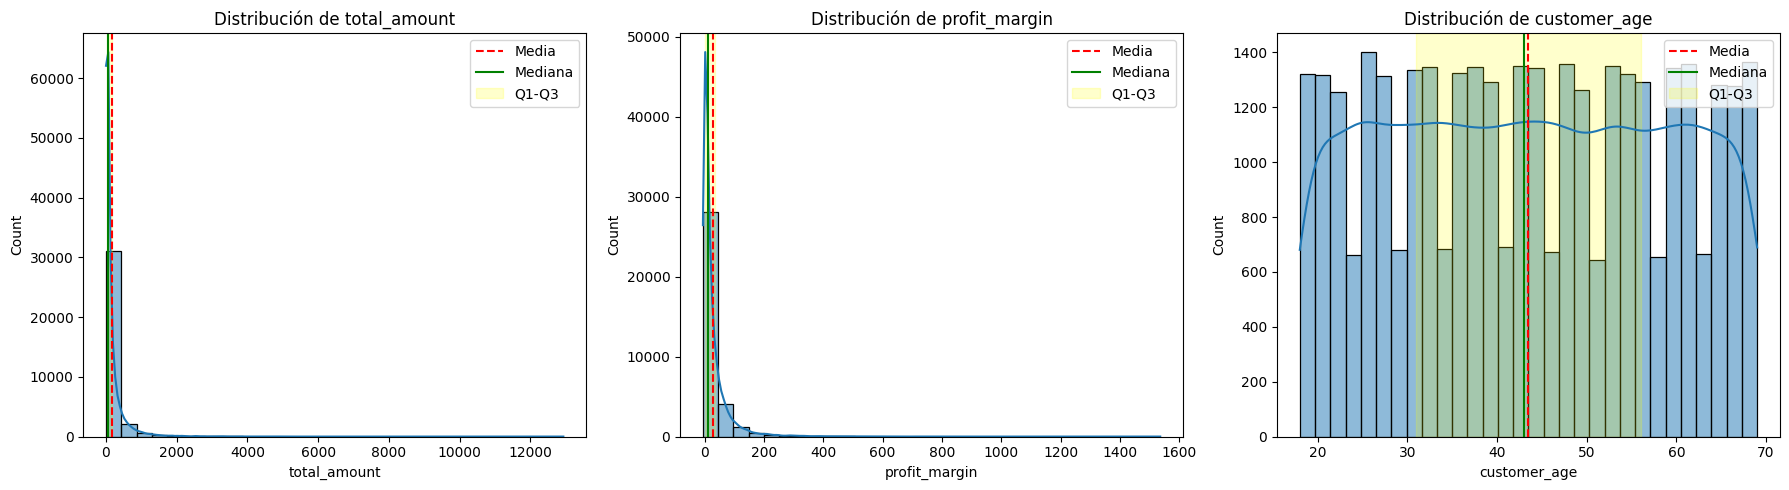

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = ['total_amount', 'profit_margin', 'customer_age']

fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, var in enumerate(variables):

    media = df[var].mean()
    mediana = df[var].median()
    q1 = df[var].quantile(0.25)
    q3 = df[var].quantile(0.75)

    sns.histplot(df[var], kde=True, bins=30, ax=axes[i])

    axes[i].axvline(media, color='red', linestyle='--', label='Media')
    axes[i].axvline(mediana, color='green', linestyle='-', label='Mediana')

    axes[i].axvspan(q1, q3, alpha=0.2, color='yellow', label='Q1-Q3')

    axes[i].set_title(f'Distribución de {var}')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [5]:
df_clean = df.copy()

variables = ['total_amount','profit_margin']

filas_originales = len(df_clean)

for var in variables:

    q1 = df_clean[var].quantile(0.25)
    q3 = df_clean[var].quantile(0.75)
    iqr = q3 - q1

    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    df_clean = df_clean[(df_clean[var] >= lim_inf) & (df_clean[var] <= lim_sup)]

filas_finales = len(df_clean)

print("Filas originales:", filas_originales)
print("Filas eliminadas:", filas_originales - filas_finales)
print("Filas restantes:", filas_finales)

Filas originales: 34500
Filas eliminadas: 5822
Filas restantes: 28678


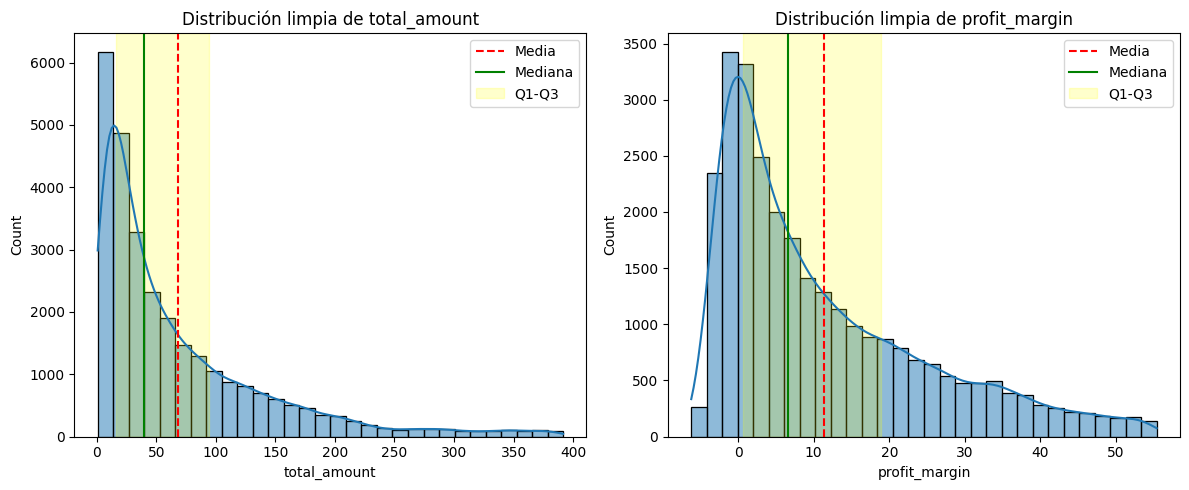

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = ['total_amount', 'profit_margin']

fig, axes = plt.subplots(1, 2, figsize=(12,5))

for i, var in enumerate(variables):

    media = df_clean[var].mean()
    mediana = df_clean[var].median()
    q1 = df_clean[var].quantile(0.25)
    q3 = df_clean[var].quantile(0.75)

    sns.histplot(df_clean[var], kde=True, bins=30, ax=axes[i])

    axes[i].axvline(media, color='red', linestyle='--', label='Media')
    axes[i].axvline(mediana, color='green', linestyle='-', label='Mediana')

    axes[i].axvspan(q1, q3, alpha=0.2, color='yellow', label='Q1-Q3')

    axes[i].set_title(f'Distribución limpia de {var}')
    axes[i].legend()

plt.tight_layout()
plt.show()

Las distribuciones originales de total_amount y profit_margin presentan
asimetría positiva (sesgo hacia la derecha), lo cual es común en datos
de ventas donde existen algunos valores muy altos.

Tras eliminar los valores atípicos usando el método del IQR, las
distribuciones se vuelven más simétricas y concentradas alrededor de
la media y mediana, reduciendo el efecto de valores extremos.

La distribución de customer_age se aproxima más a una forma normal
comparada con las variables monetarias.

# Bloque 3: Análisis Univariante de variables categóricas (1.5 pts)

Vamos a analizar las variables categóricas:
+ category: Para entender qué tipo de productos dominan el mercado.
+ payment_method: Fundamental para ver hábitos financieros y posibles comisiones.
+ region: Para identificar áreas geográficas con mayor volumen de negocio.
+ returned: Vital para analizar la tasa de fracaso de las ventas (logística inversa)

__En celdas de código independientes:__

1. Calcular y mostrar de cada variable: Moda, valores únicos.

2. Frecuencia de Categorías: Calcular el número de pedidos por cada category y mostrarlo en un gráfico de barras y de tartas.
   
3. Preferencia de Pago: Crear un gráfico de tarta para visualizar la distribución porcentual de los payment_method.

4. Análisis de Devoluciones por Región: Crear un gráfico de barras apilado o agrupado que muestre la cantidad de productos devueltos (returned) frente a los no devueltos, desglosado por region.

5. Responder en __markdown__ las categorias dominantes, porcentaje de devoluciones por región y conclusiones obtenidas.

In [7]:
categoricas = ['category', 'payment_method', 'region', 'returned']

for var in categoricas:

    moda = df[var].mode()[0]
    valores_unicos = df[var].unique()

    print(f"\nVariable: {var}")
    print(f"Moda: {moda}")
    print(f"Valores únicos: {valores_unicos}")
    print(f"Número de categorías: {len(valores_unicos)}")


Variable: category
Moda: Fashion
Valores únicos: ['Home' 'Grocery' 'Electronics' 'Beauty' 'Fashion' 'Toys' 'Sports']
Número de categorías: 7

Variable: payment_method
Moda: Credit Card
Valores únicos: ['Credit Card' 'UPI' 'COD' 'PayPal' 'Debit Card' 'Wallet']
Número de categorías: 6

Variable: region
Moda: South
Valores únicos: ['West' 'South' 'North' 'East' 'Central']
Número de categorías: 5

Variable: returned
Moda: No
Valores únicos: ['No' 'Yes']
Número de categorías: 2


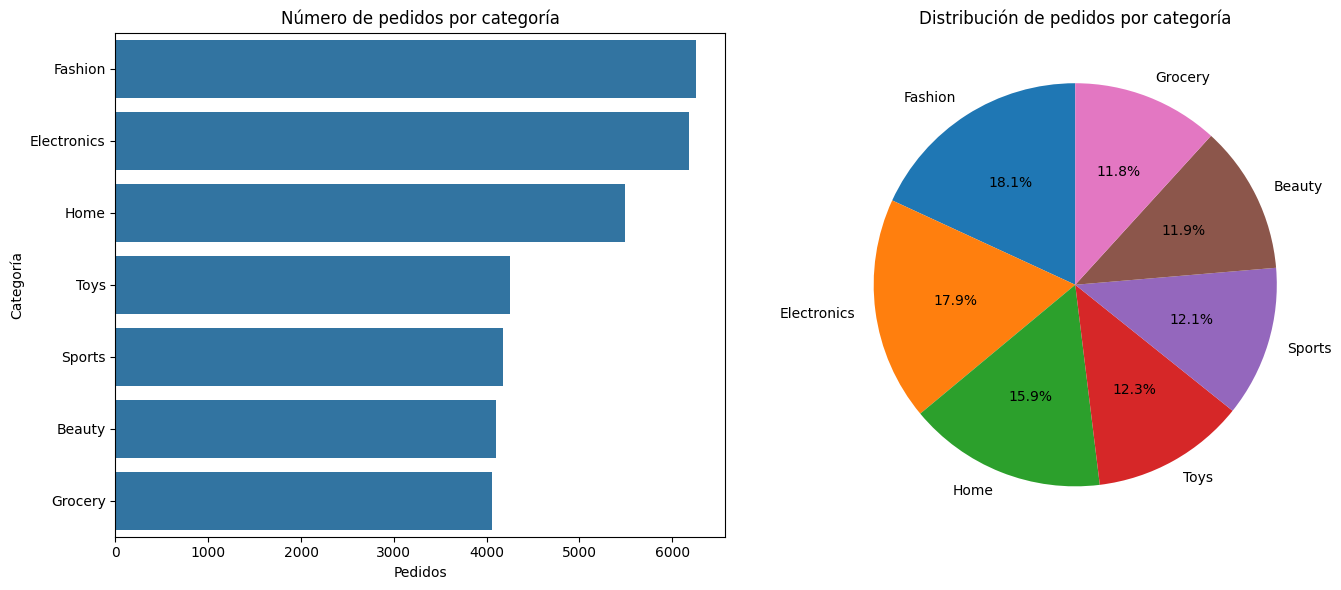

In [8]:
cat_counts = df['category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# --- barras ---
sns.barplot(
    x=cat_counts.values,
    y=cat_counts.index,
    ax=axes[0]
)

axes[0].set_title("Número de pedidos por categoría")
axes[0].set_xlabel("Pedidos")
axes[0].set_ylabel("Categoría")


# --- tarta ---
axes[1].pie(
    cat_counts.values,
    labels=cat_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

axes[1].set_title("Distribución de pedidos por categoría")


plt.tight_layout()
plt.show()

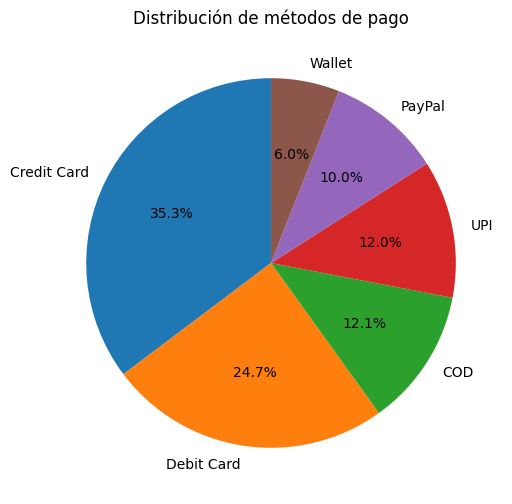

In [9]:
payment_counts = df['payment_method'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribución de métodos de pago")

plt.show()

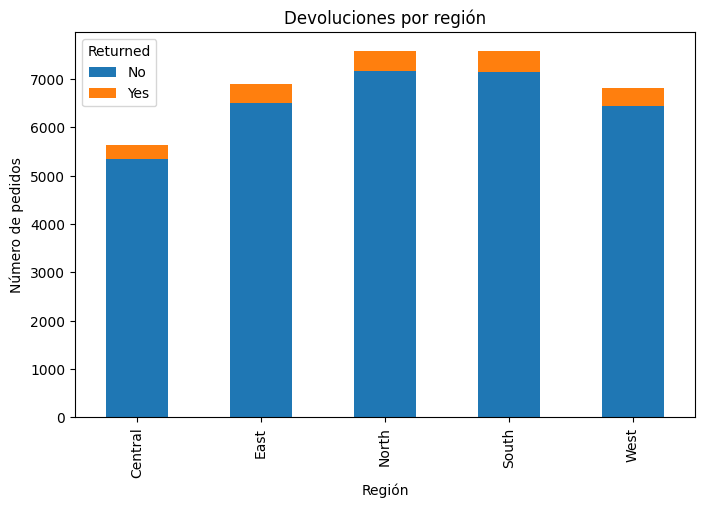

In [10]:
tabla_dev = pd.crosstab(df['region'], df['returned'])

tabla_dev.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title("Devoluciones por región")
plt.xlabel("Región")
plt.ylabel("Número de pedidos")

plt.legend(title="Returned")

plt.show()

## Conclusiones del análisis categórico

Las categorías de productos muestran que algunas concentran la mayor parte de las ventas,
lo que indica qué segmentos dominan el mercado.

En los métodos de pago se observa una preferencia clara por determinados medios,
lo cual puede ser útil para analizar costes de comisión o estrategias de pago.

El análisis por región permite identificar qué zonas generan mayor volumen de negocio
y cómo se distribuyen las devoluciones.

Finalmente, el gráfico de devoluciones muestra que algunas regiones presentan
una tasa de devolución más alta, lo que podría estar relacionado con factores
logísticos, satisfacción del cliente o tipo de producto vendido.

# Bloque 4: Análisis de Segmentación y ANOVA sobre variable método de pago (2 pts)

Sobre el DF original.

__En celdas de código independientes:__

1. Boxplots: Visualizar el beneficio (profit_margin) según __método de pago__.
   
2. Analizar Outliers: Calcula y muestra el límite superior que marca cada outliter para cada medio de pago y cuántos outliers tiene cada medio.

3. Limpia los outliers calculados anteriormente en una copia del DF.

4. Ejecutar un test ANOVA sobre el DF limpio para determinar si el método de pago influye significativamente en el beneficio.

5. Comenta en __markdown__ si hay diferencias.

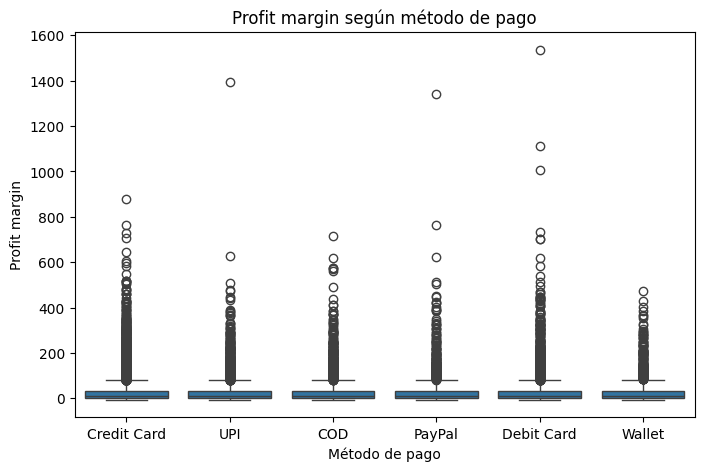

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='payment_method',
    y='profit_margin'
)

plt.title("Profit margin según método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Profit margin")

plt.show()

In [12]:
outliers_info = []

for metodo, grupo in df.groupby('payment_method'):

    q1 = grupo['profit_margin'].quantile(0.25)
    q3 = grupo['profit_margin'].quantile(0.75)

    iqr = q3 - q1

    limite_sup = q3 + 1.5 * iqr

    n_outliers = (grupo['profit_margin'] > limite_sup).sum()

    outliers_info.append({
        "payment_method": metodo,
        "limite_superior": limite_sup,
        "num_outliers": n_outliers
    })

outliers_df = pd.DataFrame(outliers_info)

outliers_df

,payment_method,limite_superior,num_outliers
0,COD,81.47125,340
1,Credit Card,80.33750,1079
2,Debit Card,80.11500,773
3,PayPal,82.82500,273
4,UPI,79.19500,383
5,Wallet,82.43500,175


In [13]:
df_clean = df.copy()

for metodo, grupo in df_clean.groupby('payment_method'):

    q1 = grupo['profit_margin'].quantile(0.25)
    q3 = grupo['profit_margin'].quantile(0.75)

    iqr = q3 - q1

    limite_sup = q3 + 1.5 * iqr
    limite_inf = q1 - 1.5 * iqr

    df_clean = df_clean[
        ~(
            (df_clean['payment_method'] == metodo) &
            (
                (df_clean['profit_margin'] > limite_sup) |
                (df_clean['profit_margin'] < limite_inf)
            )
        )
    ]

print("Filas originales:", len(df))
print("Filas después de limpiar:", len(df_clean))

Filas originales: 34500
Filas después de limpiar: 31477


In [14]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

modelo = smf.ols('profit_margin ~ C(payment_method)', data=df_clean).fit()

anova_table = sm.stats.anova_lm(modelo, typ=2)

anova_table

,sum_sq,df,F,PR(>F)
C(payment_method),2.867770e+03,5.0,1.492644,0.18844
Residual,1.209285e+07,31471.0,NaN,NaN


## 5. Conclusiones

El test ANOVA permite evaluar si el método de pago tiene un efecto significativo
sobre el beneficio.

Si el p-valor es menor que 0.05, se puede concluir que existen diferencias
estadísticamente significativas entre al menos dos métodos de pago.

En caso contrario, no se puede afirmar que el método de pago influya de forma
significativa en el profit margin.

# Bloque 5: Análisis de Segmentación y ANOVA sobre variable category (2 pts)

Sobre el DF original.

__En celdas de código independientes:__

1. Boxplots: Visualizar el beneficio (profit_margin) según la __categoría__ del producto.
   
2. Analizar Outliers: Calcula y muestra el límite superior que marca cada outliter para cada categoría y cuántos outliers tiene una.

3. Limpia los outliers calculados anteriormente en una copia del DF.

4. Vuelve a mostrar el Boxplot sin los outliers(usa el parámetro showfliers=False para que no se vean de nuevo los atípicos)

5. Ejecutar un test ANOVA sobre el DF limpio para determinar si la categoría influye significativamente en el beneficio.

6. Ejecutar el Test de Tukey.

7. Comenta en __markdown__ si hay diferencias y categorías más importantes.

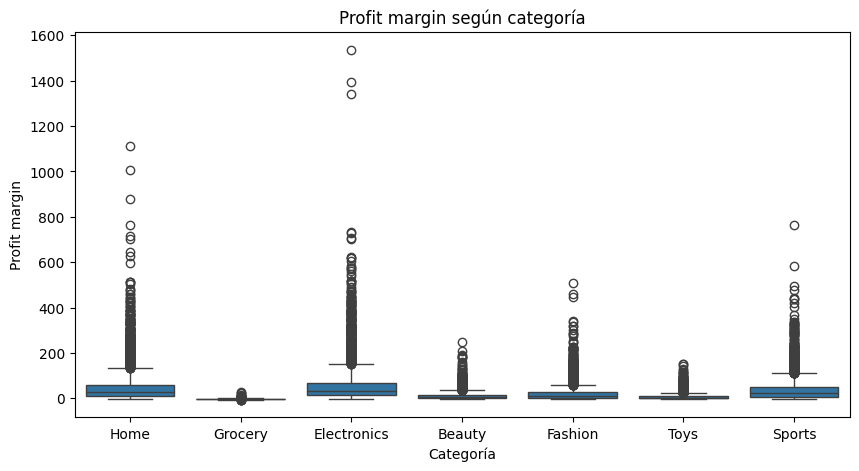

In [15]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='category',
    y='profit_margin'
)

plt.title("Profit margin según categoría")
plt.xlabel("Categoría")
plt.ylabel("Profit margin")

plt.show()

In [16]:
outliers_info = []

for categoria, grupo in df.groupby('category'):

    q1 = grupo['profit_margin'].quantile(0.25)
    q3 = grupo['profit_margin'].quantile(0.75)

    iqr = q3 - q1

    limite_sup = q3 + 1.5 * iqr

    n_outliers = (grupo['profit_margin'] > limite_sup).sum()

    outliers_info.append({
        "category": categoria,
        "limite_superior": limite_sup,
        "num_outliers": n_outliers
    })

outliers_df = pd.DataFrame(outliers_info)

outliers_df

,category,limite_superior,num_outliers
0,Beauty,34.7425,330
1,Electronics,151.9475,455
2,Fashion,59.8275,439
3,Grocery,0.9400,85
4,Home,135.2125,399
5,Sports,110.1475,300
6,Toys,24.9900,326


In [17]:
df_clean_cat = df.copy()

for categoria, grupo in df_clean_cat.groupby('category'):

    q1 = grupo['profit_margin'].quantile(0.25)
    q3 = grupo['profit_margin'].quantile(0.75)

    iqr = q3 - q1

    limite_sup = q3 + 1.5 * iqr
    limite_inf = q1 - 1.5 * iqr

    df_clean_cat = df_clean_cat[
        ~(
            (df_clean_cat['category'] == categoria) &
            (
                (df_clean_cat['profit_margin'] > limite_sup) |
                (df_clean_cat['profit_margin'] < limite_inf)
            )
        )
    ]

print("Filas originales:", len(df))
print("Filas después de limpiar:", len(df_clean_cat))

Filas originales: 34500
Filas después de limpiar: 32161


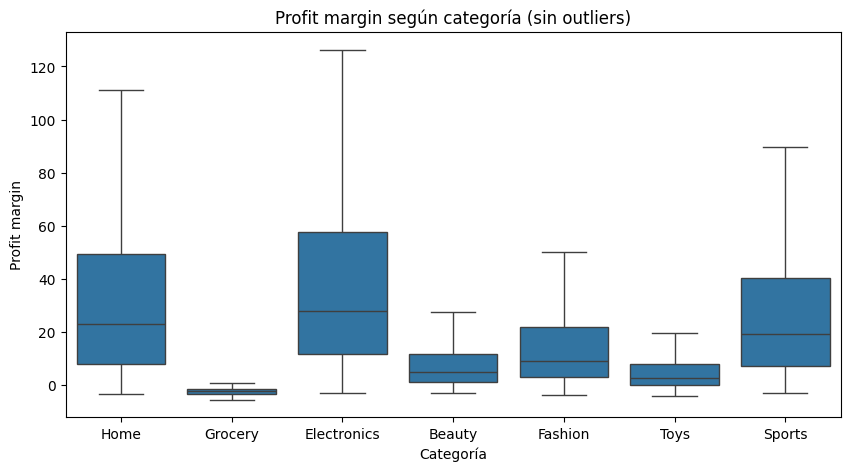

In [18]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=df_clean_cat,
    x='category',
    y='profit_margin',
    showfliers=False
)

plt.title("Profit margin según categoría (sin outliers)")
plt.xlabel("Categoría")
plt.ylabel("Profit margin")

plt.show()

In [19]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

modelo = smf.ols('profit_margin ~ C(category)', data=df_clean_cat).fit()

anova_table = sm.stats.anova_lm(modelo, typ=2)

anova_table

,sum_sq,df,F,PR(>F)
C(category),6.800917e+06,6.0,2219.77731,0.0
Residual,1.641882e+07,32154.0,NaN,NaN


In [20]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df_clean_cat['profit_margin'],
    groups=df_clean_cat['category'],
    alpha=0.05
)

print(tukey)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
   group1      group2   meandiff p-adj  lower    upper   reject
---------------------------------------------------------------
     Beauty Electronics  31.3905   0.0  29.9933  32.7876   True
     Beauty     Fashion   6.4842   0.0   5.0914    7.877   True
     Beauty     Grocery -10.0261   0.0 -11.5411   -8.511   True
     Beauty        Home  25.3989   0.0  23.9674  26.8304   True
     Beauty      Sports   19.811   0.0  18.2867  21.3353   True
     Beauty        Toys  -2.8013   0.0  -4.3208  -1.2818   True
Electronics     Fashion -24.9063   0.0 -26.1468 -23.6658   True
Electronics     Grocery -41.4165   0.0 -42.7928 -40.0402   True
Electronics        Home  -5.9916   0.0  -7.2753  -4.7078   True
Electronics      Sports -11.5795   0.0 -12.9659  -10.193   True
Electronics        Toys -34.1918   0.0 -35.5729 -32.8106   True
    Fashion     Grocery -16.5103   0.0 -17.8822 -15.1383   True
    Fashion        Home  18.9147   0.0  

## 7. Conclusiones

El test ANOVA permite comprobar si existen diferencias significativas en el
beneficio (`profit_margin`) entre las distintas categorías de productos.

Si el p-valor del ANOVA es menor que 0.05, se concluye que al menos una categoría
presenta un beneficio medio diferente.

El test de Tukey permite identificar exactamente qué pares de categorías
presentan diferencias significativas.

A partir de este análisis se pueden identificar las categorías más rentables
y aquellas con menor margen de beneficio.

# Bloque 6: Análisis Bivariante - Relaciones de 2 variables (1.5 pts)

__En celdas de código independientes:__

1. Correlación: Matriz de correlación y visualización con un Heatmap de Seaborn de todas las variables numéricas.

2. Dispersión: Gráfico de puntos (Scatter plot) con recta de regresión entre los 3 pares más correlacionados.

In [21]:
numericas = df.select_dtypes(include=['int64','float64'])

corr_matrix = numericas.corr()

corr_matrix

,price,discount,quantity,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age
price,1.000000,0.008736,0.005324,0.007612,0.801426,0.654110,0.679105,-0.010550
discount,0.008736,1.000000,-0.008431,0.002490,-0.031202,-0.046383,-0.047470,0.000181
quantity,0.005324,-0.008431,1.000000,0.005120,0.304134,0.278292,0.388398,0.000352
delivery_time_days,0.007612,0.002490,0.005120,1.000000,0.005495,0.007651,0.005832,0.003624
total_amount,0.801426,-0.031202,0.304134,0.005495,1.000000,0.599079,0.893327,-0.009870
shipping_cost,0.654110,-0.046383,0.278292,0.007651,0.599079,1.000000,0.616730,-0.008951
profit_margin,0.679105,-0.047470,0.388398,0.005832,0.893327,0.616730,1.000000,-0.007712
customer_age,-0.010550,0.000181,0.000352,0.003624,-0.009870,-0.008951,-0.007712,1.000000


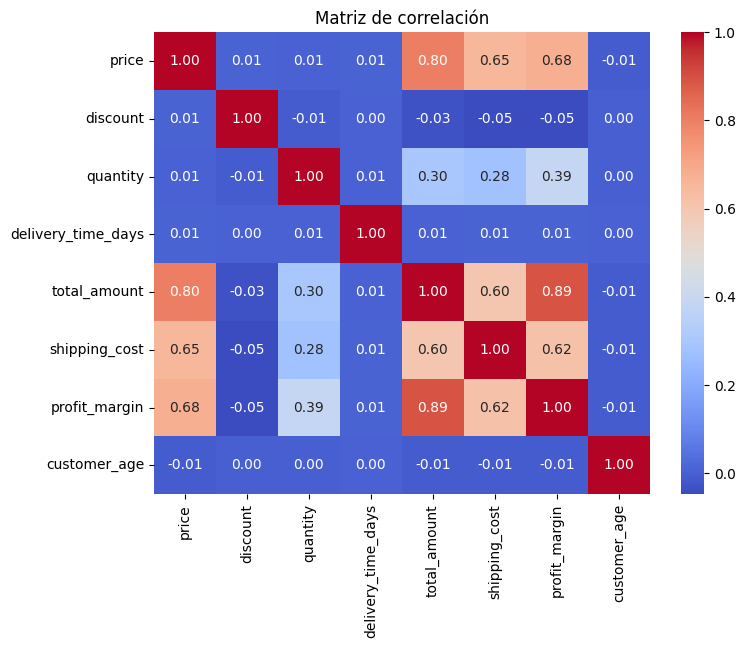

In [22]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Matriz de correlación")
plt.show()

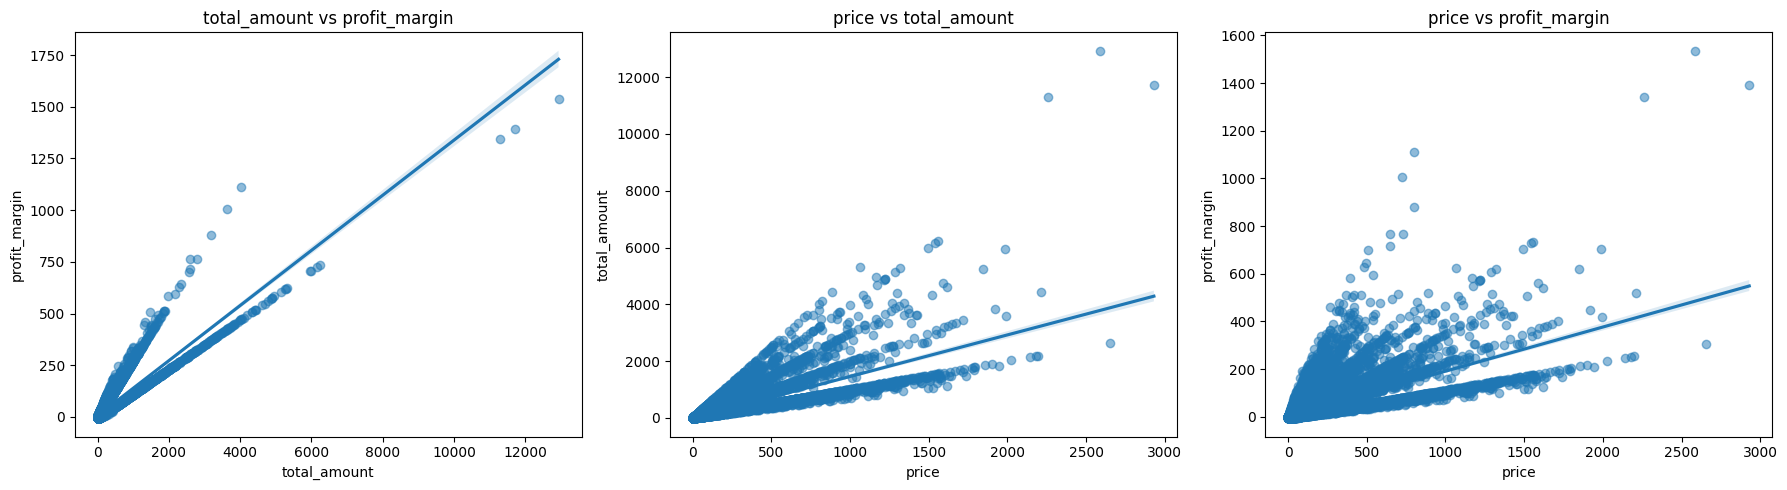

In [23]:
pares = [
    ('total_amount', 'profit_margin'),
    ('price', 'total_amount'),
    ('price', 'profit_margin')
]
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for i, (x, y) in enumerate(pares):

    sns.regplot(
        data=df,
        x=x,
        y=y,
        ax=axes[i],
        scatter_kws={"alpha":0.5}
    )

    axes[i].set_title(f"{x} vs {y}")

plt.tight_layout()
plt.show()

# Bloque 7: Análisis de Series Temporales (1.5 pts)

__En celdas de código independientes:__

1. Tendencia: 3 gráfico de líneas diferentes para mostrar la evolución a lo largo del tiempo: las ventas diarias (items), ingresos (total_amount) y margen (profit_margin). Primero debes agrupar datos por día. 

2. Suavizado: Aplicar una media móvil de 30 días para ver la tendencia sin ruido.

3. Agrupar las ventas por mes y graficar con barras. 3 Gráficos: ventas, ignresos y margen.

4. Analiza los datos mostrados en una celda __markdown__.

In [30]:
df['order_date'] = pd.to_datetime(df['order_date'])

ventas_dia = df.groupby('order_date').agg({
    'quantity':'sum',
    'total_amount':'sum',
    'profit_margin':'sum'
}).reset_index()

ventas_dia.head()

,order_date,quantity,total_amount,profit_margin
0,2023-09-12,55,6727.75,1148.55
1,2023-09-13,58,9678.11,1507.96
2,2023-09-14,47,5622.59,721.55
3,2023-09-15,56,5531.77,934.28
4,2023-09-16,52,10853.21,1524.93


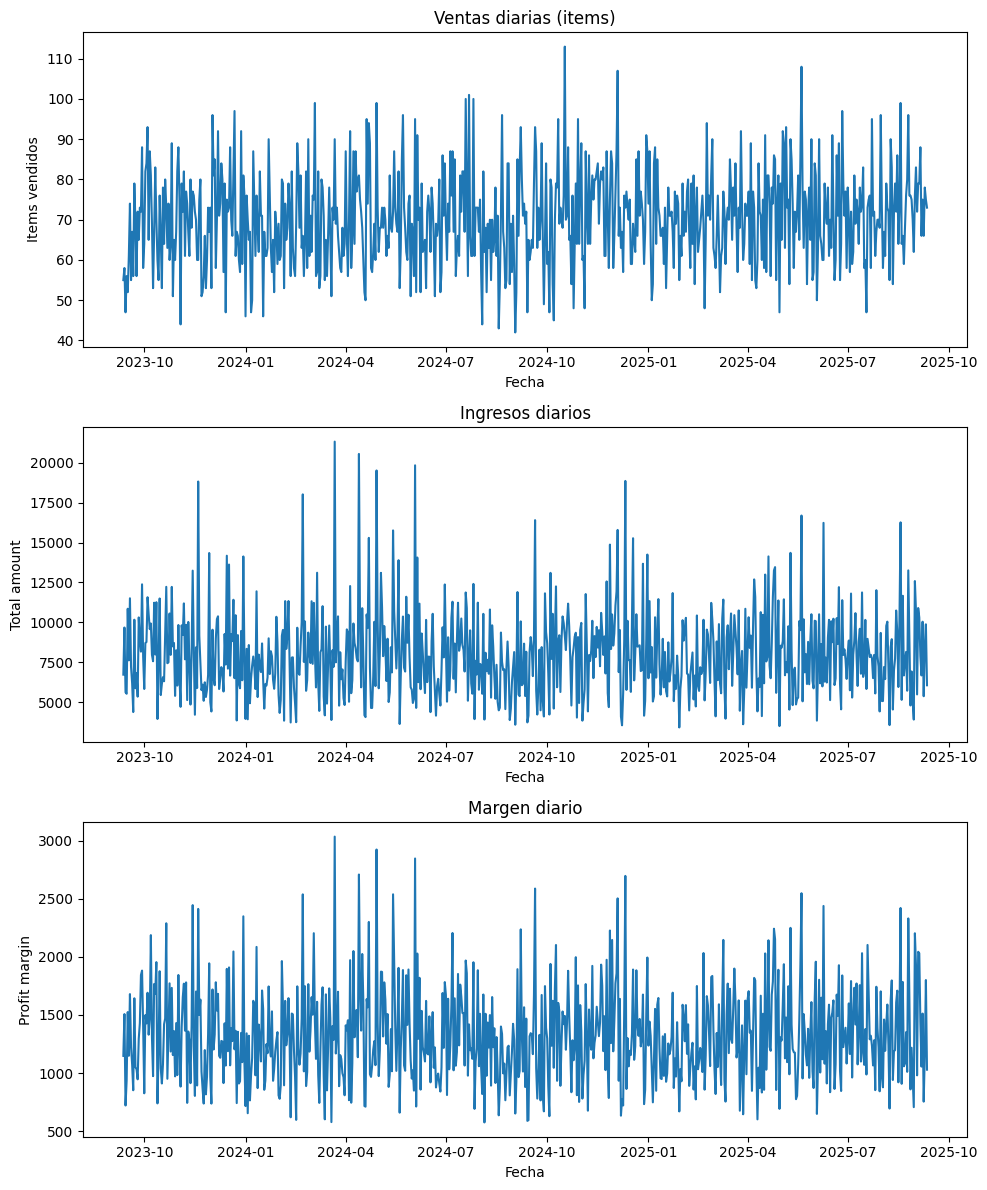

In [31]:
fig, axes = plt.subplots(3,1, figsize=(10,12))

# ventas
axes[0].plot(ventas_dia['order_date'], ventas_dia['quantity'])
axes[0].set_title("Ventas diarias (items)")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Items vendidos")

# ingresos
axes[1].plot(ventas_dia['order_date'], ventas_dia['total_amount'])
axes[1].set_title("Ingresos diarios")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Total amount")

# margen
axes[2].plot(ventas_dia['order_date'], ventas_dia['profit_margin'])
axes[2].set_title("Margen diario")
axes[2].set_xlabel("Fecha")
axes[2].set_ylabel("Profit margin")

plt.tight_layout()
plt.show()

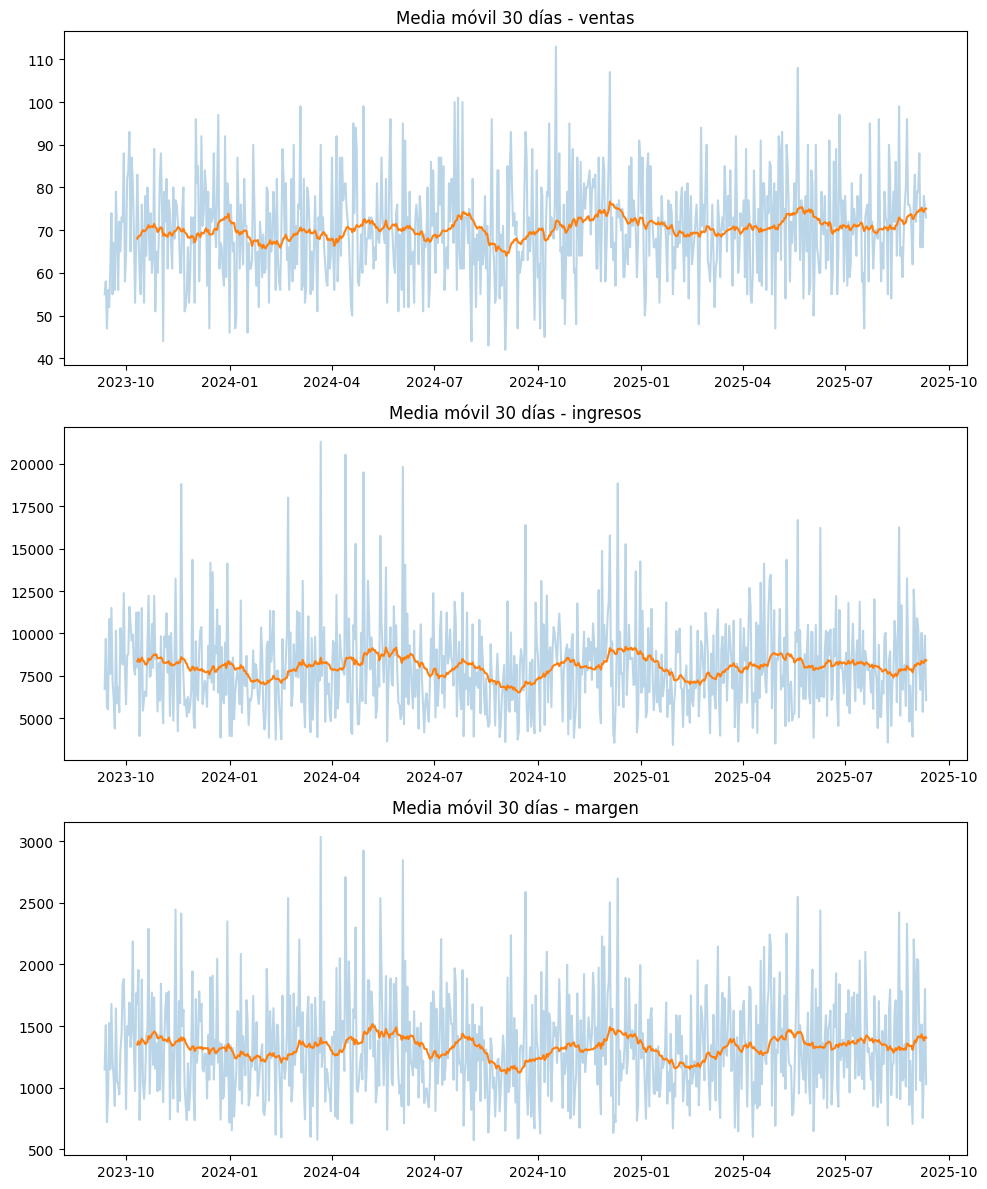

In [33]:
ventas_dia['items_ma30'] = ventas_dia['quantity'].rolling(window=30).mean()
ventas_dia['total_amount_ma30'] = ventas_dia['total_amount'].rolling(window=30).mean()
ventas_dia['profit_margin_ma30'] = ventas_dia['profit_margin'].rolling(window=30).mean()

fig, axes = plt.subplots(3,1, figsize=(10,12))

# ventas
axes[0].plot(ventas_dia['order_date'], ventas_dia['quantity'], alpha=0.3)
axes[0].plot(ventas_dia['order_date'], ventas_dia['items_ma30'])
axes[0].set_title("Media móvil 30 días - ventas")

# ingresos
axes[1].plot(ventas_dia['order_date'], ventas_dia['total_amount'], alpha=0.3)
axes[1].plot(ventas_dia['order_date'], ventas_dia['total_amount_ma30'])
axes[1].set_title("Media móvil 30 días - ingresos")

# margen
axes[2].plot(ventas_dia['order_date'], ventas_dia['profit_margin'], alpha=0.3)
axes[2].plot(ventas_dia['order_date'], ventas_dia['profit_margin_ma30'])
axes[2].set_title("Media móvil 30 días - margen")

plt.tight_layout()
plt.show()

In [34]:
ventas_mes = df.groupby(df['order_date'].dt.to_period('M')).agg({
    'quantity':'sum',
    'total_amount':'sum',
    'profit_margin':'sum'
}).reset_index()

ventas_mes['order_date'] = ventas_mes['order_date'].astype(str)

ventas_mes.head()

,order_date,quantity,total_amount,profit_margin
0,2023-09,1213,151135.60,24346.72
1,2023-10,2178,262502.74,43048.19
2,2023-11,2049,240286.91,40044.23
3,2023-12,2269,255617.03,41385.45
4,2024-01,2043,217766.09,37604.38


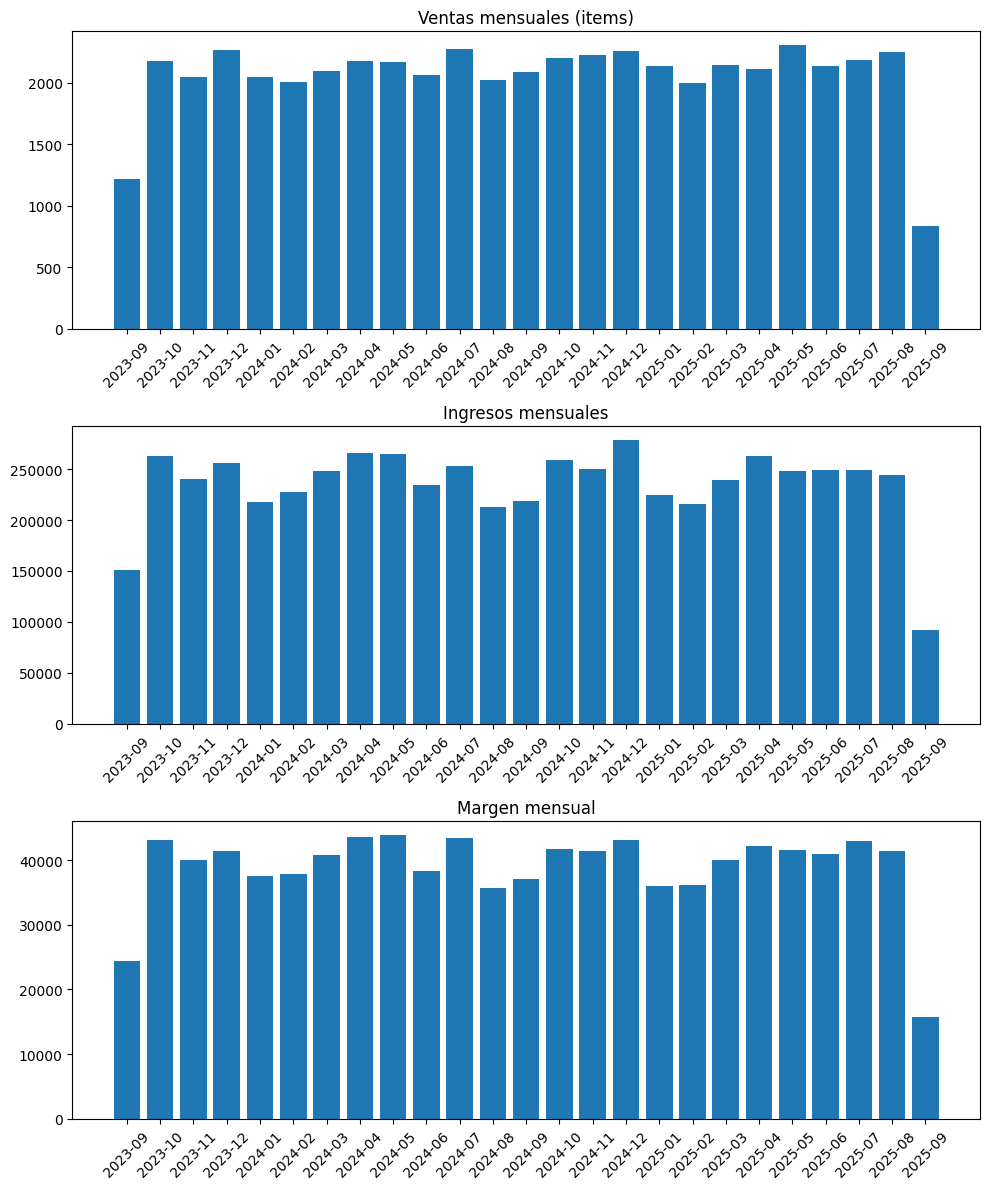

In [36]:
fig, axes = plt.subplots(3,1, figsize=(10,12))

# ventas
axes[0].bar(ventas_mes['order_date'], ventas_mes['quantity'])
axes[0].set_title("Ventas mensuales (items)")
axes[0].tick_params(axis='x', rotation=45)

# ingresos
axes[1].bar(ventas_mes['order_date'], ventas_mes['total_amount'])
axes[1].set_title("Ingresos mensuales")
axes[1].tick_params(axis='x', rotation=45)

# margen
axes[2].bar(ventas_mes['order_date'], ventas_mes['profit_margin'])
axes[2].set_title("Margen mensual")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Conclusiones

El análisis temporal permite observar cómo evolucionan las ventas, los ingresos
y el margen a lo largo del tiempo.

Los gráficos diarios muestran variabilidad debido al comportamiento natural de
las ventas. La media móvil de 30 días permite identificar mejor la tendencia
general del negocio eliminando parte del ruido.

La agregación mensual facilita la identificación de patrones de crecimiento,
disminución o posibles efectos estacionales en las ventas.